In [336]:
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import clear_output
import time
import random as rd


In [337]:
try:
    import keras
    import tensorflow
except:
    %pip install keras_preprocessing -qqq
    %pip install keras -qqq
    %pip install tensorflow -qqq
    %pip install pyserial -qqq
    %pip install matplotlib -qqq
    import keras
    import tensorflow
    import serial

In [338]:
import serial
serial.Serial()

Serial<id=0x7f4ac2ea5810, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)

In [339]:
%pip install pyserial -qqq


Note: you may need to restart the kernel to use updated packages.


In [340]:
from keras_preprocessing import image as img

In [341]:
from PIL import Image

In [342]:
path_port_serial = "/dev/ttyUSB1"
baudrate = 115200

In [343]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [344]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Bin[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*2**(BitsPorSimbolo))
      Ain[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*2**(BitsPorSimbolo))
  return [Ain,Bin]

In [345]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [346]:
def send_matrix_rec(X,input,fs_pc2fpga_rate):
  file = open(f"teste{input}.txt","+w")
   
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = baudrate
  s.bytesize = 8

  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    conc = 0
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      conc += X[j][i]*pow(10,j)
      time.sleep(1/fs_pc2fpga_rate)
    if(fs_pc2fpga_rate <10):
      strr = str(conc)[::-1]
      print(f'{strr}',"\n")
  s.write(bytearray([0xad]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xda]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

In [347]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    #s.timeout = .5#(size**2+2)/baudrate
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    a = s.read()
    print(a)
    #if(a != 239 and a != 254):
    #    return Y
    while(True):
        try:
            a = s.read()[0]
        except IndexError:
            print("Matriz corrompida...")
            return Y
        if(a==b''):
            print("Vazio")
            return Y
        if(a!=0 and a!=254 and a!=239 and a!= 255):

            i+=1
            Y[index_row][index_col] = a
            index_col +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_col = 0
        if(i == size**2 or flag ):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [348]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [349]:
def transmitter_uart(M,fs_pc2fpga_rate):
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M_p)
    send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate)
    send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate)

In [350]:

def torneio(taxa_de_transferencia,quantidade_de_op,dimensao_das_matrizes):
    ZEROS = np.zeros((dimensao_das_matrizes,dimensao_das_matrizes))
    fail =0
    bytes_enviados = 0
    bytes_recebidos = 0
    operandos_corrompidos= 0
    for i in range(quantidade_de_op+1):
        #time.sleep(((10*(dimensao_das_matrizes**2)))/baudrate)

        bytes_enviados += 2*((2*dimensao_das_matrizes-1)*dimensao_das_matrizes)*8
        bytes_recebidos += (dimensao_das_matrizes**2)*8
        clear_output(wait=True)
        print("-"*100," 100%")
        print("-"*int(100*(((i+1)/quantidade_de_op))),(i*100)/quantidade_de_op,"%")

        M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
        try:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(i))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")
        except ZeroDivisionError:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(1))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")

        X =M[0]@M[1]
        #print_matrix(X)
        transmitter_uart(M,taxa_de_transferencia)
        #time.sleep(1)
        #time.sleep(((1*(dimensao_das_matrizes**2)))/baudrate)
        #time.sleep(2)
        Y = receiver_uart(dimensao_das_matrizes)


        #print_matrix(Y)
        plt.subplot(1,2,1)
        plt.title("Calculo de Referência: PC")
        plt.imshow(X)
        plt.subplot(1,2,2)
        plt.title("Calculo obtido: FPGA")
        plt.imshow(Y)
        plt.show()
        cmp = compar_matrix(X,Y)
        operandos_corrompidos_cpm = compar_matrix(Y,ZEROS)
        if(cmp):
            fail+=1
            #return M
            #break

        if(not(operandos_corrompidos_cpm)):
            operandos_corrompidos +=1

        print("\n\n Falha" if cmp else "\n\n Sucesso",end='\n')

    return ((quantidade_de_op-fail)/(quantidade_de_op))*100,(operandos_corrompidos/quantidade_de_op)*100

In [351]:
#torneio(taxa_de_transferencia=baudrate,quantidade_de_op=100000,dimensao_das_matrizes=16)


In [352]:
from keras.preprocessing.image import img_to_array

# Visão de escalabilidade e requisitos

Text(0, 0.5, 'Requisito Systolic')

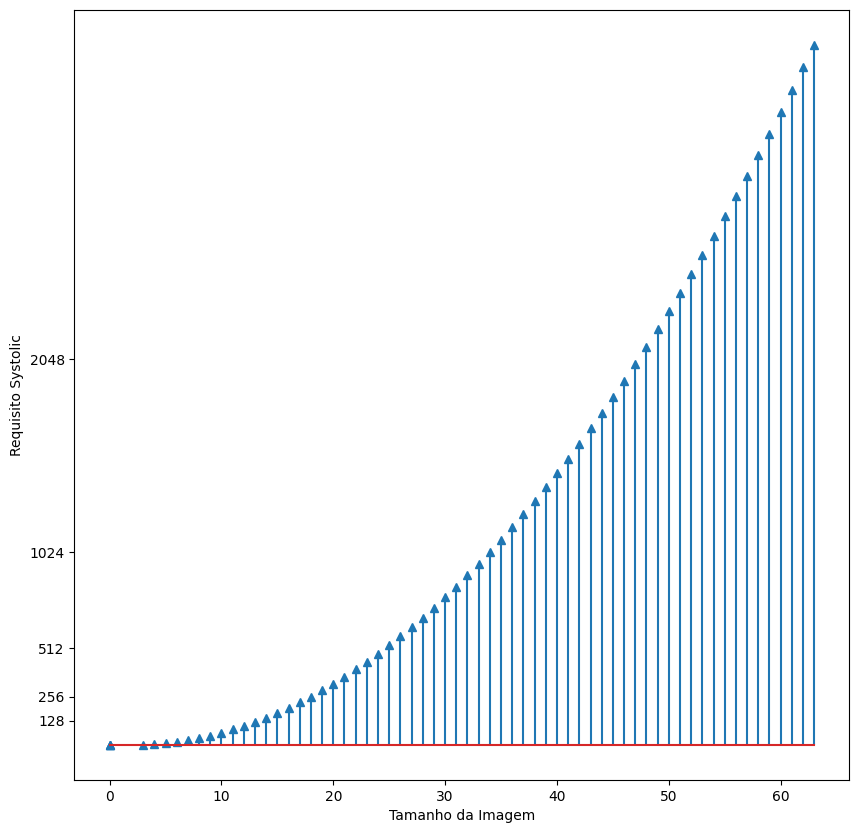

In [353]:
sizt =64
sizek = 3
sizeSystolicCore = np.zeros(sizt)
sizeImagemProcessada = np.zeros(sizt)

for i in range(sizek,sizt):
    #(Imagem-1)**2==Systolic
    sizeImagemProcessada[i-sizek] =i
    sizeSystolicCore[i-sizek] = 2**(np.log2((i-sizek+1)**2))

plt.figure(figsize=(10,10))
desl = 7
plt.yticks([2**(i+desl) for i in range(sizt-desl)])
plt.stem(sizeImagemProcessada,sizeSystolicCore,markerfmt="^")
plt.xlabel("Tamanho da Imagem")
plt.ylabel("Requisito Systolic")

In [354]:
K1 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
K1 = np.array([[1,1,1],[1,9,1],[1,1,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K1 = np.array([[1,1,1],[1,1,1],[1,1,1]])/2
K2 = np.array([[-1,0,-1],[-2,0,2],[-1,0,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K2=K1
M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
#K = np.array([[1,0],[0,-1]])
#K = np.array([[0,0],[0,1]])


In [355]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [356]:

imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [357]:
image = imga.resize([sizt, sizt])



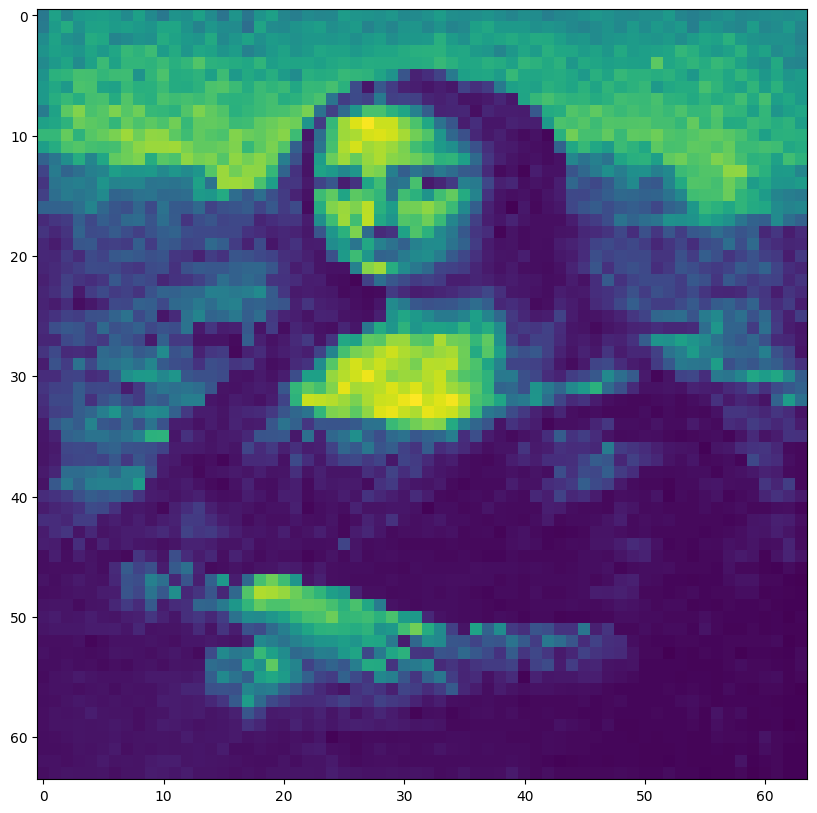

In [358]:
IMAG1 = img_to_array(image).reshape(sizt,sizt)
plt.figure(figsize=(10,10))
plt.imshow(IMAG1)
#IMAG = M

In [359]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 32):
                image_norm[i][j] = 9
            else:
                image_norm[i][j] = 1
    return image_norm

In [360]:
IMAG = normalizeImage(IMAG1)

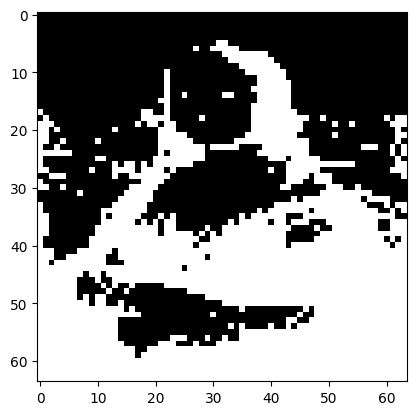

In [361]:
plt.imshow(IMAG,cmap="binary")

In [362]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [363]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int((sizeMinicial))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[0][k]

            k+=1

    return Mout



In [364]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    sizel = M.shape[0]
    sizec = M.shape[1]
    Mout = np.zeros((sizeKernel**2,int((sizel-sizeKernel+1)**2)))
    k = 0
    for i in range(0,sizel-sizeKernel+1):
        for j in range(0,sizec-sizeKernel+1):
            '''Melhorias futuras'''
            X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            Mout[0][k+0] = X0
            Mout[1][k+0] = X1
            Mout[2][k+0] = X2
            Mout[3][k+0] = X3
            Mout[4][k+0] = X4
            Mout[5][k+0] = X5
            Mout[6][k+0] = X6
            Mout[7][k+0] = X7
            Mout[8][k+0] = X8
            #X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            #Mout[0+0][k+0] = X0
            #Mout[0+1][k+0] = X1
            #Mout[0+2][k+0] = X2
            #Mout[0+3][k+0] = X3

            #print(X0,X1,X2,X3)
            k+=1
    return Mout

In [365]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget),dtype=int)
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    for i in range(size_lin):
        for j in  range(size_row):
            matrixMout[i][j] = matrix[i][j]
            #print("Aqui",matrix[i][j])
    return matrixMout
    


In [366]:
def conv2mult(sizeTarget, inputConv,inputK):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =sizeTarget)
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=sizeTarget)
    return [matrix_target_kernel,matrix_target_image]

### Kernel no domíno base

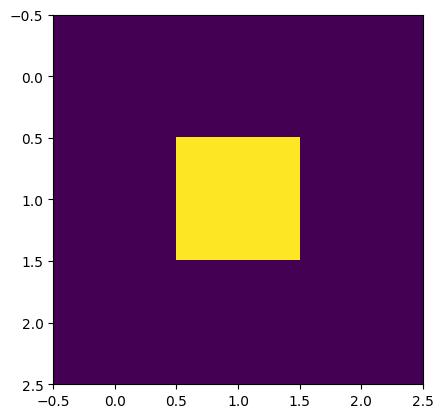

In [367]:
plt.imshow(K1)

### Imagem no domínio base

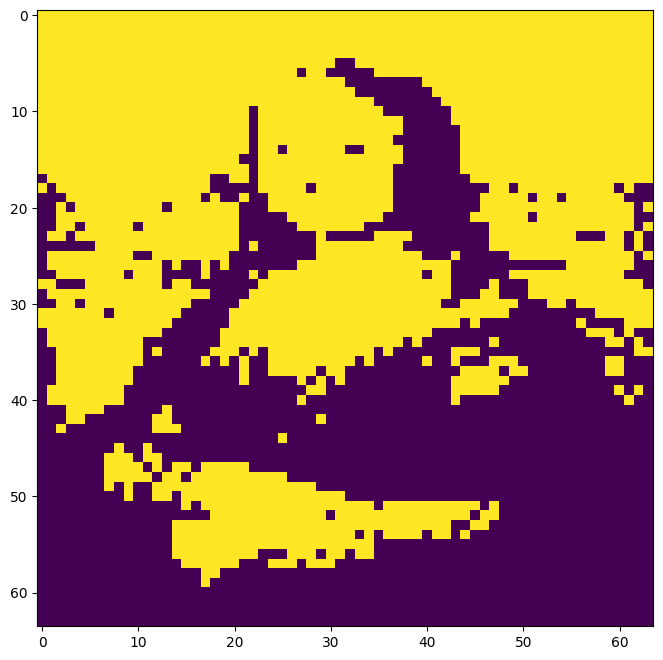

In [368]:
plt.figure(figsize=(8,8))
plt.imshow(IMAG)

In [369]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 4):
                image_norm[i][j] = 1
            else:
                image_norm[i][j] = 0
    return image_norm

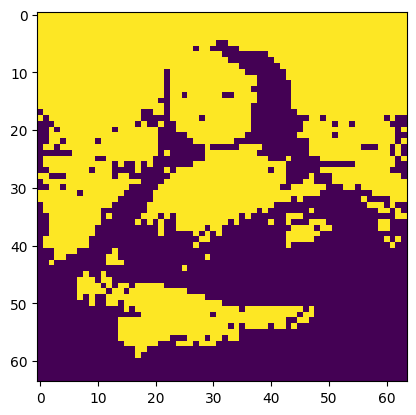

In [370]:
plt.imshow(normalizeImage(IMAG))

In [371]:
#IMAG = normalizeImage(IMAG)

In [372]:
IMAG.max()

np.int64(9)

In [373]:
#plt.figure(figsize=(500,1000))
#plt.imshow(transform_matrix(IMAG,Kern=K).T)

In [374]:
requi = 2**int(np.log2((IMAG.shape[0]-sizek)**2)+1)
print("Requisito do multiplicador:", requi)

Requisito do multiplicador: 4096


In [375]:
A1,B1 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K1)
A2,B2 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K2)

## Kernel no novo domínio com expansão dos operandos

In [376]:
#plt.subplot(1,2,1)
#plt.imshow(A1)
#plt.subplot(1,2,2)
#plt.imshow(A2)

## Imagem no novo domínio com expansão dos operandos


In [377]:
##@plt.subplot(1,2,1)
##@plt.imshow(B1)
##@plt.subplot(1,2,2)
##@plt.imshow(B2)


In [378]:
Mout_vec1 = A1
Mout_vec2 = A2

#Resultado da Convolução no novo domínio com expansão dos operandos

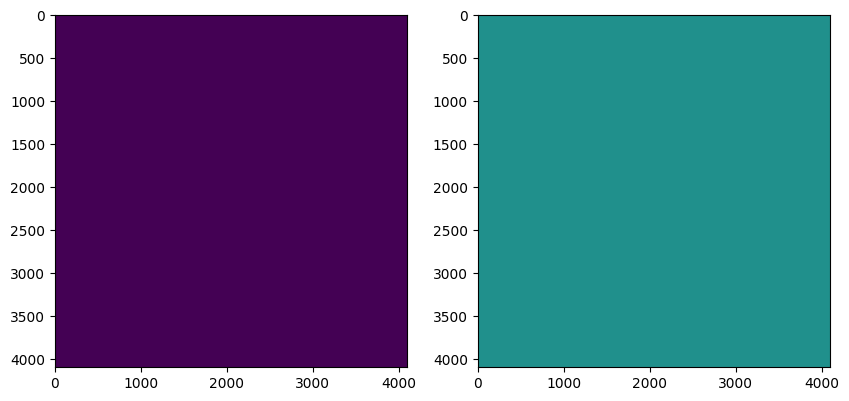

In [379]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(Mout_vec1)
plt.subplot(1,2,2)
plt.imshow(Mout_vec2)
plt.show()

#Resultado da Convolução no domínio base

In [380]:
Mout_vec1[:][0].shape

(4096,)

62
62


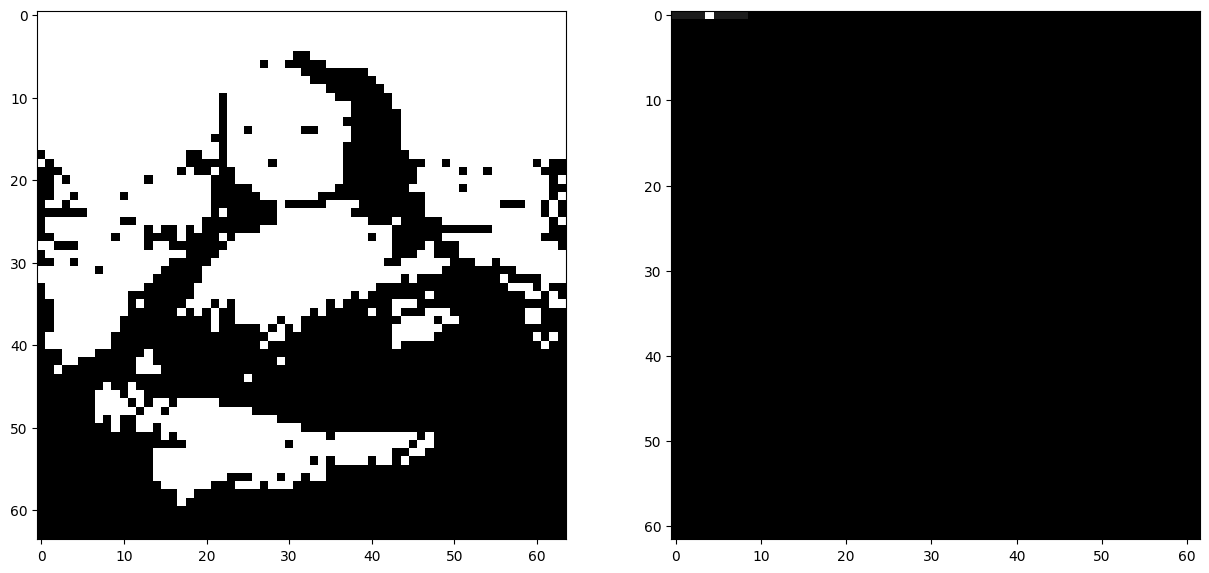

In [381]:
cmap = "gray"
Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
plt.figure(figsize=(15,15))
plt.subplot(1,2,2)
plt.imshow(Mout1,cmap=cmap)
plt.subplot(1,2,1)
plt.imshow(IMAG,cmap=cmap)
plt.show()

62
62


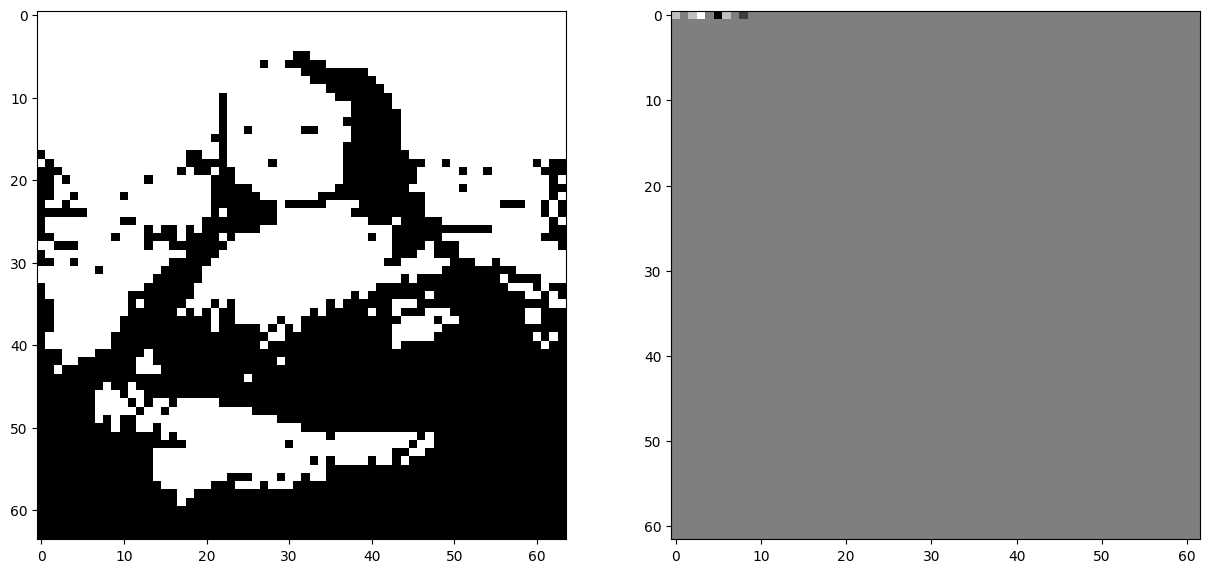

In [382]:
cmap1 = "gray"
cmap2= "binary"
Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
plt.figure(figsize=(15,15))
plt.subplot(1,2,2)
plt.imshow(Mout2,cmap=cmap2)
plt.subplot(1,2,1)
plt.imshow(IMAG,cmap=cmap1)
plt.show()

62
62


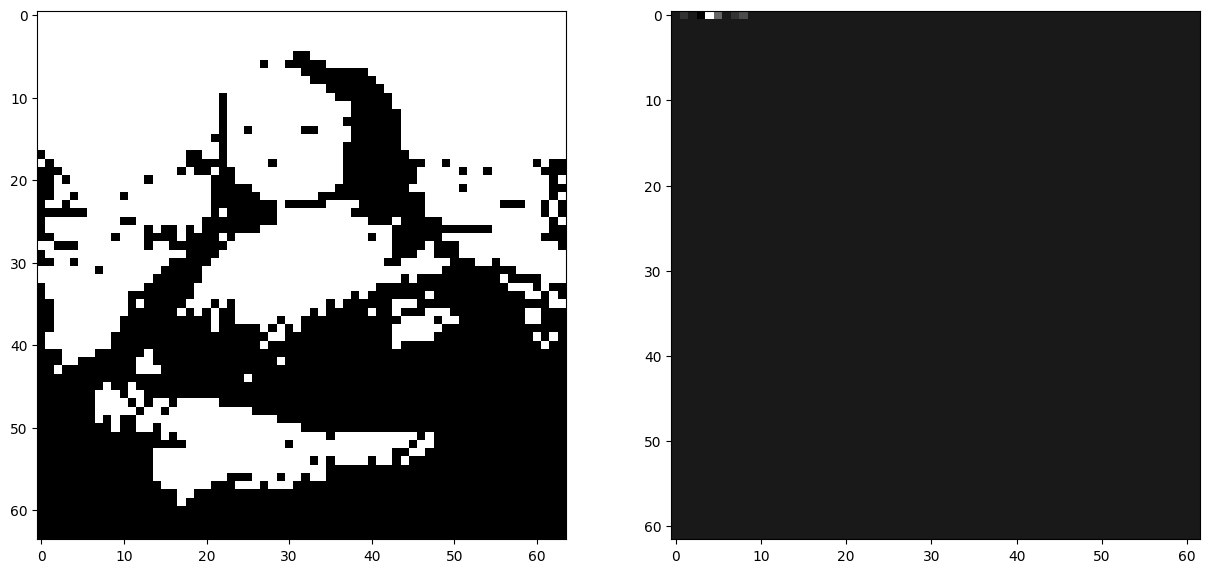

In [383]:
cmap1 = "gray"
cmap2= "gray"
Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
plt.figure(figsize=(15,15))
plt.subplot(1,2,2)
plt.imshow(Mout2+Mout1,cmap=cmap2)
plt.subplot(1,2,1)
plt.imshow(IMAG,cmap=cmap1)
plt.show()

In [384]:
def windows_slice(imagem,windows_size,imag_size):

    '''Esta função retornará uma pequena fatia da imagem base, dada uma posição relativa. Com o tamanho da unidade de mulltiplicação'''
    window_buffer = np.zeros((windows_size,windows_size))
    
    try:
        for k in range(windows_size):
             for h in range(windows_size):
                window_buffer[k][h] = imagem[windows_slice.posy_static+k][windows_slice.posx_static+h]
    except:
        print("Fora do limite da imagem, posx e posy < imag_size")
        windows_slice.posx_static = 0
        windows_slice.posy_static = 0
    windows_slice.posx_static +=3
    if(windows_slice.posx_static > imag_size-windows_size):
        windows_slice.posx_static = 0
        windows_slice.posy_static +=3
    print(windows_slice.posx_static,windows_slice.posy_static)
    return (window_buffer,windows_slice.posy_static == imag_size-windows_size)


In [385]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

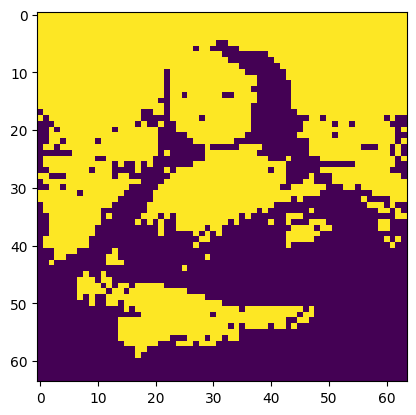

In [386]:
plt.imshow(IMAG)

In [387]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

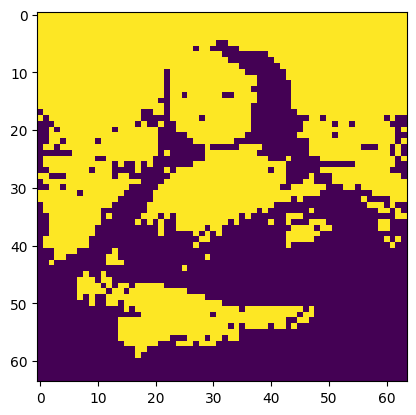

In [388]:
plt.imshow(IMAG)


In [389]:
def rebuild_image(windows_buffer_conv,size_imag,size_mult,windows_size):

    for k in range(size_mult):
     for h in range(size_mult):
        rebuild_image.window_buffer[rebuild_image.posy+k][rebuild_image.posx+h] = windows_buffer_conv[k][h]
    rebuild_image.posx +=3
    if(rebuild_image.posx > size_imag-windows_size):
        rebuild_image.posy +=3
        rebuild_image.posx  = 0

6 9
14


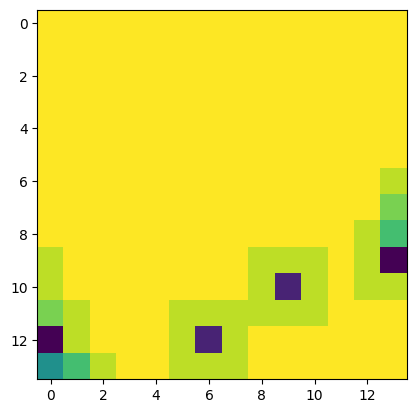

(14, 14) (256, 256) (256, 256)


In [390]:
windows_size =16# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    time.sleep(1/20)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=256,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

In [ ]:
A[1]= A[0]
A[2]= A[0]
A[3]= A[0]


In [ ]:
A

array([[1, 1, 1, 1, 9, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 9, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 9, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 9, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

# Ambiente de convolução na PC

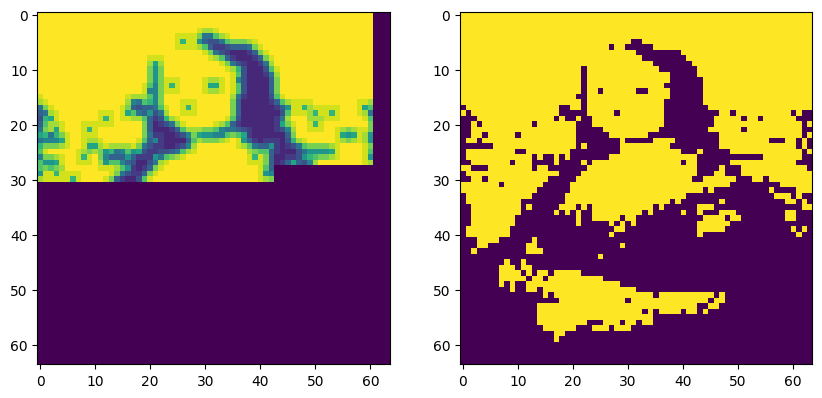

<Figure size 1000x1000 with 0 Axes>

45 27
4


KeyboardInterrupt: 

In [ ]:
windows_size =6# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/60)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=16,inputConv=windows_buffer,inputK=K1)
    A[1]= A[0]
    A[2]= A[0]
    A[3]= A[0]

    Asyst=abs(A)+1#Problemas no envio do kernel com zeros
    Asyst
    Bsyst = B#normalização de 4 bits
    ResultMult = Asyst@Bsyst #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.subplot(1,2,1)
    plt.imshow(Asyst)
    plt.subplot(1,2,2)

    plt.imshow(Bsyst)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()

# Ambiente de convolução na FPGA

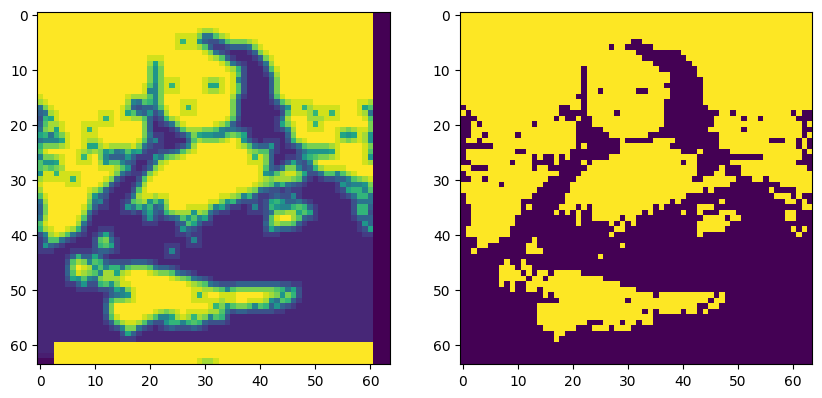

<Figure size 1000x1000 with 0 Axes>

3 3
b'\xfe'
4


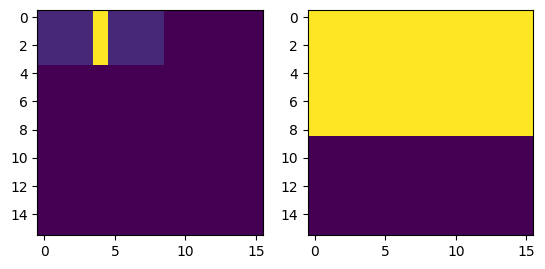

(4, 4) (16, 16) (16, 16)


IndexError: index 64 is out of bounds for axis 0 with size 64

In [ ]:
windows_size =6# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/60)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=16,inputConv=windows_buffer,inputK=K1)
    A[1]= A[0]
    A[2]= A[0]
    A[3]= A[0]
    Asyst=abs(A)+1#Problemas no envio do kernel com zeros
    Asyst
    Bsyst = B#normalização de 4 bits
    M_p = shiftMatrixSystolic(Asyst,Bsyst)
    send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
    send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
    ResultMult = receiver_uart(size=16)
    ResultMult
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.subplot(1,2,1)
    plt.imshow(A)
    plt.subplot(1,2,2)

    plt.imshow(B)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()

array([[ 4,  4,  4,  4, 11,  4,  4,  4,  4,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,

In [ ]:
Asyst=abs(A)+1
Asyst
Bsyst = B//16



In [ ]:
Asyst=abs(A)+1
Asyst
Bsyst = B//16
M_p = shiftMatrixSystolic(Asyst,Bsyst)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=16)
ResultMult

b'\xfe'


KeyboardInterrupt: 

In [ ]:
ResultMult = receiver_uart(size=16)
ResultMult

b'\xfe'


array([[165, 180, 175, 177, 171, 175, 172, 186, 173, 173, 177, 188, 179,
        190, 180, 191],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  6

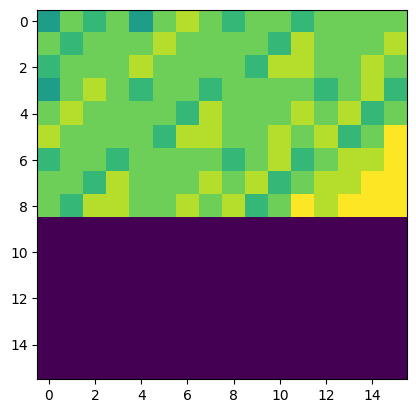

In [ ]:
plt.imshow(B//16)

In [ ]:

def torneio(taxa_de_transferencia,quantidade_de_op,dimensao_das_matrizes):
    ZEROS = np.zeros((dimensao_das_matrizes,dimensao_das_matrizes))
    fail =0
    bytes_enviados = 0
    bytes_recebidos = 0
    operandos_corrompidos= 0
    for i in range(quantidade_de_op+1):
        #time.sleep(((10*(dimensao_das_matrizes**2)))/baudrate)

        bytes_enviados += 2*((2*dimensao_das_matrizes-1)*dimensao_das_matrizes)*8
        bytes_recebidos += (dimensao_das_matrizes**2)*8
        clear_output(wait=True)
        print("-"*100," 100%")
        print("-"*int(100*(((i+1)/quantidade_de_op))),(i*100)/quantidade_de_op,"%")

        M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=2)
        try:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(i))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")
        except ZeroDivisionError:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(1))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")

        X =M[0]@M[1]
        #print_matrix(X)
        transmitter_uart(M,taxa_de_transferencia)
        #time.sleep(1)
        #time.sleep(((1*(dimensao_das_matrizes**2)))/baudrate)
        #time.sleep(2)
        #Y = receiver_uart(dimensao_das_matrizes)
        #print_matrix(Y)
        plt.subplot(1,2,1)
        plt.title("Calculo de Referência: PC")
        plt.imshow(X)
        plt.subplot(1,2,2)
        plt.title("Calculo obtido: FPGA")
        #plt.imshow(Y)
        plt.show()
        cmp = compar_matrix(X,X)
        operandos_corrompidos_cpm = compar_matrix(X,ZEROS)
        if(cmp):
            fail+=1
            #return M
            #break

        if(not(operandos_corrompidos_cpm)):
            operandos_corrompidos +=1

        print("\n\n Falha" if cmp else "\n\n Sucesso",end='\n')

    return ((quantidade_de_op-fail)/(quantidade_de_op))*100,(operandos_corrompidos/quantidade_de_op)*100
torneio(taxa_de_transferencia=baudrate,quantidade_de_op=1000,dimensao_das_matrizes=16)

----------------------------------------------------------------------------------------------------  100%
--- 3.5 %
Taxa de Transferência =  115200  3.50 / 100 | fail:  0 |Pass:  35  |Pass(%):  100.00  |Operandos Corrompidos:  0  | Bytes enviados:  0.285696 MBytes  |Bytes recebidos 0.073728 MBytes
[array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 3, 2, 2, 2, 4,
        4, 2, 3, 4, 3, 2, 4, 2, 3],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 2, 4, 4, 3, 4,
        4, 4, 2, 2, 2, 2, 4, 4, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 2, 3, 4, 4, 2, 2,
        3, 2, 2, 3, 3, 4, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 2, 4, 3, 4, 3, 3, 4, 2,
        2, 4, 2, 2, 4, 4, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 4, 2, 3, 3, 4, 4, 4, 3, 2,
        2, 2, 2, 2, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 2, 4, 4, 2, 3, 4, 2, 2, 4,
        2, 3, 3, 4, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2

KeyboardInterrupt: 

In [ ]:
windows_size =6# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
taxa_de_transferencia = 115200
dimensao_das_matrizes = 16
while(True):
    time.sleep(1)
    #Janelamento

    #Preprocessamento das Transformações
    # ------------------------------------------------------------------------------------------------------------------------
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    #Conversão de Convolução para Multiplicação + Normalização das dimensões
    M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)
    #print(A.shape)
    #plt.subplot(1,3,1)
    #plt.imshow(A)
    #plt.subplot(1,3,2)
    #plt.imshow(B)
    #plt.subplot(1,3,2)
    #plt.imshow(B)
    print(M[1].max())
    #M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
    print(M[1].max())

    #-------------------------------------------------------------------------------------------------------------------------
    # Cálculo na FPGA 
    #-------------------------------------------------------------------------------------------------------------------------
    #Preprocessamento do Systolic
    transmitter_uart(M,taxa_de_transferencia)
    ResultMult = receiver_uart(size=dimensao_das_matrizes)
    #-------------------------------------------------------------------------------------------------------------------------
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    #--------------------------------------------------------------------------------------------------------------------------
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

1 0
154
154
[array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0

KeyboardInterrupt: 

<Figure size 800x800 with 0 Axes>

In [ ]:
A,B=create_matrix(16,1)
M_p = shiftMatrixSystolic(A,B)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=dimensao_das_matrizes)
ResultMult


b'\xfe'


array([[36, 38, 33, 39, 32, 40, 41, 30, 39, 39, 36, 38, 40, 38, 35, 42],
       [42, 45, 43, 47, 40, 49, 48, 37, 46, 48, 43, 43, 47, 45, 42, 49],
       [32, 32, 32, 35, 30, 35, 36, 27, 34, 37, 32, 31, 33, 32, 31, 36],
       [37, 37, 37, 39, 35, 41, 41, 29, 40, 42, 37, 36, 39, 39, 36, 40],
       [36, 38, 36, 38, 33, 39, 42, 29, 40, 41, 36, 37, 40, 38, 36, 40],
       [36, 36, 36, 40, 35, 41, 41, 29, 40, 42, 36, 36, 37, 39, 34, 43],
       [35, 38, 36, 38, 32, 40, 39, 31, 37, 39, 37, 35, 39, 36, 36, 39],
       [35, 38, 36, 40, 34, 40, 39, 31, 37, 41, 37, 35, 40, 38, 34, 41],
       [41, 43, 43, 44, 37, 47, 47, 36, 45, 47, 42, 41, 45, 44, 43, 46],
       [32, 33, 35, 36, 32, 37, 38, 28, 34, 38, 33, 31, 35, 35, 33, 37],
       [35, 37, 37, 41, 34, 41, 40, 31, 39, 41, 34, 35, 40, 37, 36, 40],
       [37, 42, 39, 43, 38, 44, 43, 32, 43, 43, 39, 38, 42, 41, 37, 45],
       [37, 38, 36, 41, 34, 42, 40, 29, 41, 41, 35, 37, 39, 38, 36, 41],
       [38, 42, 38, 41, 36, 45, 43, 31, 43, 42, 38,

In [ ]:
A,B=create_matrix(16,1)
M_p = shiftMatrixSystolic(A,B)
M_p[0].shape

(16, 31)

In [ ]:
M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)


In [ ]:
M[0]

array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[1])
M_p[1].shape

In [ ]:
M_p[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 101, 119, 121, 135, 112, 127, 112, 107,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 101, 119, 122, 135, 112, 126, 112, 107, 135,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        119, 122, 123, 112, 126, 127, 107, 135, 131,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 122,
        123, 118, 126, 127, 121, 135, 131, 100,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 121, 135,
        112, 127, 112, 107, 125, 121, 115,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 135, 112, 126,
        112, 107, 135, 121,

In [ ]:
(windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
windows_buffer =windows_buffer//16

2 0


In [ ]:
M = conv2mult(sizeTarget=16,inputConv=windows_buffer,inputK=K1)

In [ ]:
M

[array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[7, 6, 7, 7, 7, 8, 7, 7, 7, 7, 6, 8, 7, 7, 7, 8],
        [6, 

In [ ]:
windows_buffer

array([[7., 6., 7., 7., 7., 7.],
       [7., 8., 7., 7., 7., 7.],
       [7., 7., 6., 8., 8., 6.],
       [7., 7., 7., 8., 7., 8.],
       [7., 8., 6., 7., 9., 7.],
       [8., 8., 9., 9., 9., 9.]])

In [ ]:
M_p = shiftMatrixSystolic(windows_buffer,M[1])


In [ ]:
M_p[0]

array([[  0,   0,   0,   0,   0, 126, 101, 119, 122, 123, 118],
       [  0,   0,   0,   0, 121, 135, 112, 126, 127, 121,   0],
       [  0,   0,   0, 127, 112, 107, 135, 131, 100,   0,   0],
       [  0,   0, 125, 121, 115, 128, 118, 130,   0,   0,   0],
       [  0, 119, 128, 107, 126, 149, 127,   0,   0,   0,   0],
       [140, 143, 154, 153, 145, 150,   0,   0,   0,   0,   0]])

In [ ]:
M_p[1]

array([[  0,   0,   0,   0,   0,  89, 126, 101,  93, 121, 135,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 126, 101, 119, 121, 135, 112,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0, 101, 119, 122, 135, 112, 126,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0, 119, 122, 123, 112, 126, 127,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,  93, 121, 135, 108, 127, 112,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [121, 135, 112, 127, 112, 107,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,

In [ ]:
conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)

[array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[126, 101, 119, 122, 121, 135, 112, 126, 127, 112, 107, 135, 1

In [ ]:
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)

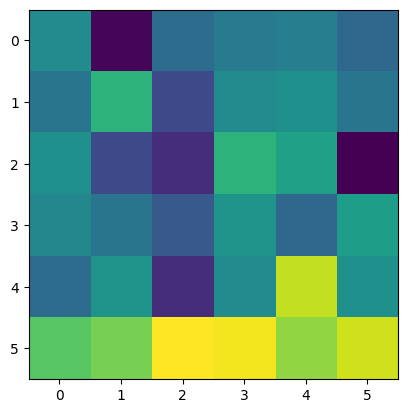

In [ ]:
plt.imshow(windows_buffer)

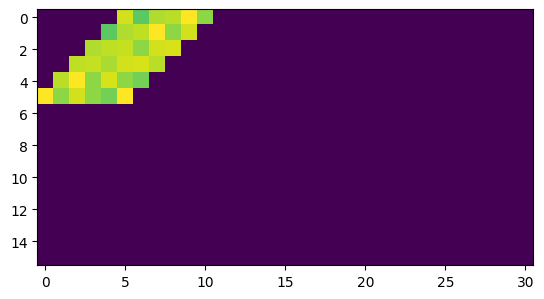

In [ ]:
plt.imshow(M_p[1])

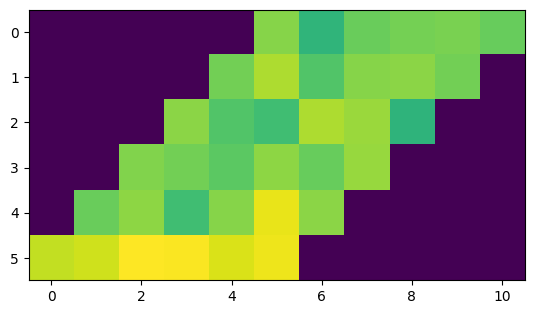

In [ ]:
plt.imshow(M_p[0])


In [ ]:
ResultMult = receiver_uart(size=dimensao_das_matrizes)
#ResultMult

b'\xfe'


KeyboardInterrupt: 

In [ ]:
M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)
M

[array([[-1, -1, -1, -1,  8, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  

In [ ]:

M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)
M_p = shiftMatrixSystolic(M[0],M[1])
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=dimensao_das_matrizes)
ResultMult

ValueError: byte must be in range(0, 256)

In [ ]:
M_p[1].max()

np.int64(7)

In [ ]:
M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=dimensao_das_matrizes)
ResultMult

b'\xfe'


KeyboardInterrupt: 

In [ ]:
windows_size =6# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/6000)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=16,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

33 1
4


KeyboardInterrupt: 

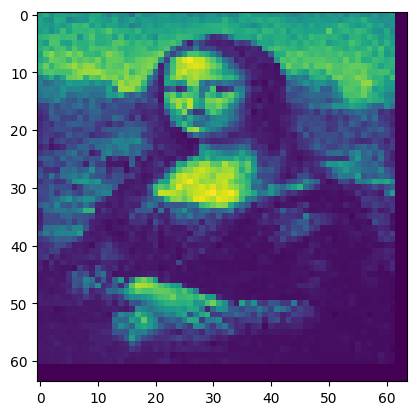

In [ ]:
plt.imshow(rebuild_image.window_buffer)